In [2]:
import numpy as np
import pandas as pd

In [9]:
df = pd.read_csv('spam.csv', encoding='latin1')
df.sample(10)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
472,ham,Nothing. I meant that once the money enters yo...,NaN,NaN,NaN
3582,ham,I sent your maga that money yesterday oh.,NaN,NaN,NaN
3260,ham,Yup i'm still having coffee wif my frens... My...,NaN,NaN,NaN
4106,spam,HOT LIVE FANTASIES call now 08707500020 Just 2...,NaN,NaN,NaN
5008,ham,My mobile number.pls sms ur mail id.convey reg...,NaN,NaN,NaN
458,ham,1.20 that call cost. Which i guess isnt bad. M...,NaN,NaN,NaN
4333,ham,Boo what time u get out? U were supposed to ta...,NaN,NaN,NaN
1137,ham,LOL ... No just was busy,NaN,NaN,NaN
1797,ham,Can i get your opinion on something first?,NaN,NaN,NaN
799,ham,"\Gimme a few\"" was &lt;#&gt; minutes ago""",NaN,NaN,NaN


In [10]:
df.shape

(5572, 5)

#1. Data Cleaning
#2. EDA (Exploratory Data Analysis)
3. Text Preprocessing
4. Model Building
5. Evaluation
6. Improvement
7. Website
8. Deployment

## 1. DATA CLEANING 

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [18]:
#Drops cols 3 because of missing data
# First, let's check the actual column names
print(df.columns.tolist())

# Then drop the columns that actually exist
# Method 1: Drop only the columns that exist
columns_to_drop = ['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']  # Removed the space after 'Unnamed: 3'


df.sample(10)

['v1', 'v2']


,v1,v2
2708,ham,"Nah, I'm a perpetual DD"
1420,ham,No. She's currently in scotland for that.
2306,ham,"Aight that'll work, thanks"
1829,spam,Hottest pics straight to your phone!! See me g...
1017,ham,Shall i send that exe to your mail id.
3843,ham,"Yeah that's what I thought, lemme know if anyt..."
1171,spam,Got what it takes 2 take part in the WRC Rally...
901,ham,How is it possible to teach you. And where.
1699,ham,Ok...
259,ham,IÛ÷m parked next to a MINI!!!! When are you c...


In [19]:
#renaming the columns
df.rename(columns={'v1': 'target', 'v2':'Text'}, inplace=True)
df.sample(10)

,target,Text
52,ham,K fyi x has a ride early tomorrow morning but ...
908,ham,WHITE FUDGE OREOS ARE IN STORES
1557,ham,Wat r u doing?
139,ham,Got c... I lazy to type... I forgot Ì_ in lect...
3069,ham,I'm now but have to wait till 2 for the bus to...
3261,ham,O shore are you takin the bus
951,ham,Shb b ok lor... Thanx...
2284,ham,"Velly good, yes please!"
1904,ham,Wah... Okie okie... Muz make use of e unlimite...
4010,spam,Please call our customer service representativ...


In [20]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [22]:
df['target'] = encoder.fit_transform(df['target'])
#converts all the ham msgs to 0 and spam to 1

In [23]:
 df.head() #shows the first 5 rows of your data

,target,Text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [24]:
#checking missing values
df.isnull().sum()

target    0
Text      0
dtype: int64

In [25]:
#check for any duplicates
df.duplicated().sum()

np.int64(403)

In [28]:
#remove duplicates
df.drop_duplicates(keep='first')
df.duplicated().sum()

np.int64(0)

In [30]:
df.shape

(5169, 2)

## 2. EDA

In [32]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

([<matplotlib.patches.Wedge at 0x13876f59940>,
 [Text(-1.014499732282844, 0.4251944181172162, 'ham'),
  Text(1.0144998708287172, -0.42519408755122207, 'spam')],
 [Text(-0.5533634903360967, 0.2319242280639361, '87.37'),
  Text(0.553363565906573, -0.231924047755212, '12.63')])

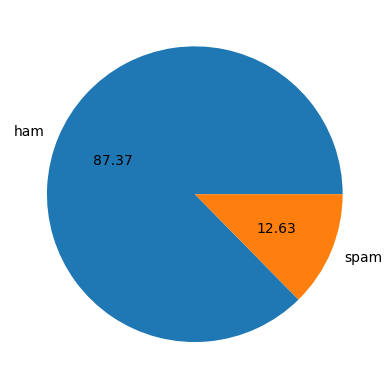

In [35]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(), labels=['ham','spam'], autopct="%0.2f")

In [ ]:
#Data is Imbalanced 